In [16]:
from __future__ import absolute_import, division, print_function
%matplotlib inline

import os
import matplotlib.pyplot as plt
import torch
import numpy as np

import networks

In [17]:
# Load all 3 models: 2 MonoDepth2 + 1 ManyDepth
monodepth_model_names = ["mono_default_weights_19", "weights_19_monoHR"]
manydepth_model_names = ["weights_19_monoHRmanydepth"]

models = []

# --- Load MonoDepth2 Models ---
for model_name in monodepth_model_names:
    model_path = os.path.join("models", model_name)
    
    encoder_path = os.path.join(model_path, "encoder.pth")
    depth_decoder_path = os.path.join(model_path, "depth.pth")

    encoder_dict = torch.load(encoder_path, map_location='cpu', weights_only=False)

    print(f"Loading {model_name} (MonoDepth2 mode)...")
    
    # Initialize Encoder
    encoder = networks.ResnetEncoder(18, False)
    
    # Initialize Decoder (Handle HR variant)
    if model_name == "weights_19_monoHR":
        depth_decoder = networks.HRDepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))
    else:
        depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))
    
    # Load State Dicts
    model_dict = encoder.state_dict()
    encoder.load_state_dict({k: v for k, v in encoder_dict.items() if k in model_dict})
    depth_decoder.load_state_dict(torch.load(depth_decoder_path, map_location='cpu'))
    
    encoder.eval()
    depth_decoder.eval()
    
    models.append({
        'name': model_name,
        'encoder': encoder,
        'decoder': depth_decoder,
        'pose_encoder': None,
        'pose_decoder': None,
        'feed_height': encoder_dict['height'],
        'feed_width': encoder_dict['width']
    })

# --- Load ManyDepth Models ---
for model_name in manydepth_model_names:
    model_path = os.path.join("models", model_name)
    
    encoder_path = os.path.join(model_path, "encoder.pth")
    depth_decoder_path = os.path.join(model_path, "depth.pth")

    encoder_dict = torch.load(encoder_path, map_location='cpu', weights_only=False)

    print(f"Loading {model_name} (ManyDepth mode)...")
    
    # Initialize Matching Encoder
    encoder = networks.ResnetEncoderMatching(
        num_layers=18,
        pretrained=False,
        input_width=encoder_dict['width'],
        input_height=encoder_dict['height'],
        adaptive_bins=True,
        min_depth_bin=0.1,
        max_depth_bin=20.0,
        depth_binning='linear',
        num_depth_bins=96
    )
    
    # Initialize Depth Decoder
    depth_decoder = networks.HRDepthDecoder(num_ch_enc=encoder.num_ch_enc)
    
    # Initialize Pose Networks
    pose_enc_path = os.path.join(model_path, "pose_encoder.pth")
    pose_dec_path = os.path.join(model_path, "pose.pth")
    
    pose_encoder = networks.ResnetEncoder(18, False, num_input_images=2)
    pose_decoder = networks.PoseDecoder(pose_encoder.num_ch_enc, num_input_features=1, num_frames_to_predict_for=2)
    
    # Load State Dicts
    model_dict = encoder.state_dict()
    encoder.load_state_dict({k: v for k, v in encoder_dict.items() if k in model_dict})
    
    depth_decoder.load_state_dict(torch.load(depth_decoder_path, map_location='cpu'))
    pose_encoder.load_state_dict(torch.load(pose_enc_path, map_location='cpu'))
    pose_decoder.load_state_dict(torch.load(pose_dec_path, map_location='cpu'))
    
    # Set all to eval
    encoder.eval()
    depth_decoder.eval()
    pose_encoder.eval()
    pose_decoder.eval()
    
    models.append({
        'name': model_name,
        'encoder': encoder,
        'decoder': depth_decoder,
        'pose_encoder': pose_encoder,
        'pose_decoder': pose_decoder,
        'feed_height': encoder_dict['height'],
        'feed_width': encoder_dict['width'],
        'min_depth_bin': encoder_dict['min_depth_bin'],
        'max_depth_bin': encoder_dict['max_depth_bin']
    })

print(f"\n✓ Successfully loaded {len(models)} models:")
for model in models:
    print(f"  - {model['name']}")


Loading mono_default_weights_19 (MonoDepth2 mode)...


/opt/homebrew/Caskroom/miniconda/base/envs/def/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/def/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loading weights_19_monoHR (MonoDepth2 mode)...
Loading weights_19_monoHRmanydepth (ManyDepth mode)...

✓ Successfully loaded 3 models:
  - mono_default_weights_19
  - weights_19_monoHR
  - weights_19_monoHRmanydepth


In [18]:
def predict_depth(model, monodepth_dir, test_index=10, manydepth=False, single_frame_mode=False):    
    kitti_dir = os.path.join(monodepth_dir, "kitti_data")
    splits_dir = os.path.join(monodepth_dir, "splits")

    from layers import transformation_from_parameters, disp_to_depth
    from utils import readlines
    filenames = readlines(os.path.join(splits_dir, "eigen", "test_files.txt"))

    frames_to_load = [0]

    if manydepth:
        # Use only previous frame to match the paper
        frames_to_load = [0, -1]

        # Set up ManyDepth model
        encoder = model['encoder']
        depth_decoder = model['decoder']
        pose_enc = model['pose_encoder']
        pose_dec = model['pose_decoder']
        height, width = model['feed_height'], model['feed_width']
        min_depth_bin = model['min_depth_bin']
        max_depth_bin = model['max_depth_bin']
    else: 
        encoder = model['encoder']
        depth_decoder = model['decoder']
        height, width = model['feed_height'], model['feed_width']

    # Set up dataset and dataloader
    from datasets import KITTIRAWDataset
    dataset = KITTIRAWDataset(kitti_dir, filenames, height, width, frames_to_load, 4, is_train=False, img_ext=".png")

    # Create DataLoader for the specific test index
    from torch.utils.data import Subset, DataLoader
    test_dataset = Subset(dataset, [test_index])
    dataloader = DataLoader(test_dataset, 1, shuffle=False, num_workers=0, drop_last=False)

    # Run inference for the selected test index
    data = next(iter(dataloader))
    input_color = data[('color', 0, 0)]
    
    if manydepth:
        # Predict poses
        pose_features = {f_i: data["color", f_i, 0] for f_i in frames_to_load}
        for fi in frames_to_load[1:]:
            pose_inputs = [pose_features[fi], pose_features[fi + 1]]
            pose_inputs = [pose_enc(torch.cat(pose_inputs, 1))]
            axisangle, translation = pose_dec(pose_inputs)
            pose = transformation_from_parameters(axisangle[:, 0], translation[:, 0], invert=True)

            # Now find 0->fi pose
            if fi != -1:
                pose = torch.matmul(pose, data[('relative_pose', fi + 1)])

            data[('relative_pose', fi)] = pose

        # Prepare lookup frames
        lookup_frames = [data[('color', idx, 0)] for idx in frames_to_load[1:]]
        lookup_frames = torch.stack(lookup_frames, 1)
        relative_poses = [data[('relative_pose', idx)] for idx in frames_to_load[1:]]
        relative_poses = torch.stack(relative_poses, 1)
        K = data[('K', 2)]
        invK = data[('inv_K', 2)]

        if single_frame_mode:
            relative_poses *= 0
                
        # Predict depth
        output, lowest_cost, costvol = encoder(input_color, lookup_frames, relative_poses, K, invK, min_depth_bin, max_depth_bin)
        output = depth_decoder(output)
    else:
        # Predict depth
        features = encoder(input_color)
        output = depth_decoder(features)

    # Convert disparity to depth
    pred_disp, _ = disp_to_depth(output[("disp", 0)], 0.1, 100.0)                
    pred_disp = pred_disp.cpu()[:, 0].detach().numpy()

    return input_color, pred_disp[0]


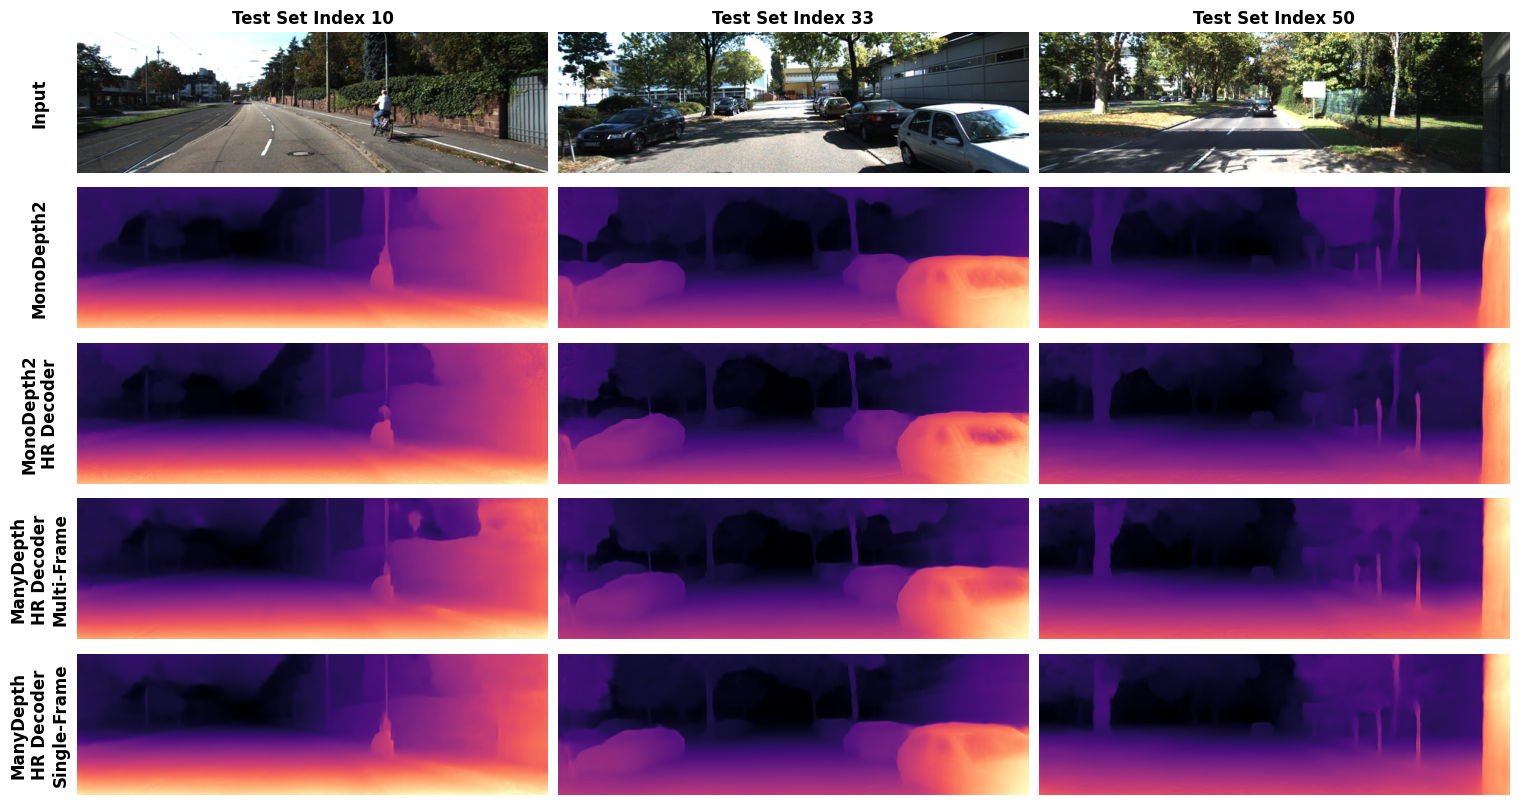

In [22]:
monodepth_dir = "/Users/david/Library/Mobile Documents/com~apple~CloudDocs/Documents/CS/MSc_Edinburgh/Semester_1/LV/project/monodepth"

# Test indices to visualize
test_indices = [10, 33, 50]

# Custom names for each model
custom_names = {
    "mono_default_weights_19": "MonoDepth2",
    "weights_19_monoHR": "MonoDepth2\nHR Decoder",
    "weights_19_monoHRmanydepth": "ManyDepth\nHR Decoder\nMulti-Frame",
    "weights_19_monoHRmanydepth (single-frame mode)": "ManyDepth\nHR Decoder\nSingle-Frame"
}

# Build list of methods to display
methods = []
for model in models:
    model_name = model['name']
    methods.append({
        'model': model,
        'label': custom_names.get(model_name, model_name),
        'manydepth': model['pose_encoder'] is not None,
        'single_frame_mode': False
    })
    if model['pose_encoder'] is not None:
        sf_key = f"{model_name} (single-frame mode)"
        methods.append({
            'model': model,
            'label': custom_names.get(sf_key, sf_key),
            'manydepth': True,
            'single_frame_mode': True
        })

# Create grid: rows = input + methods, columns = test indices
num_methods = len(methods)
num_indices = len(test_indices)
num_rows = num_methods + 1  # +1 for input image row

fig, axes = plt.subplots(num_rows, num_indices, figsize=(5 * num_indices, 1.6 * num_rows), constrained_layout=True)

# First row: display input images for each test index
for col_idx, test_index in enumerate(test_indices):
    # Get input image using the first method
    input_image, _ = predict_depth(
        methods[0]['model'], 
        monodepth_dir, 
        test_index=test_index, 
        manydepth=methods[0]['manydepth'], 
        single_frame_mode=methods[0]['single_frame_mode']
    )
    
    ax = axes[0, col_idx]
    ax.imshow(input_image[0].permute(1, 2, 0).cpu().numpy())
    ax.set_title(f"Test Set Index {test_index}", fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Add row label on the left of first column
    if col_idx == 0:
        ax.text(-0.08, 0.5, "Input", 
               transform=ax.transAxes,
               fontsize=12, fontweight='bold',
               ha='center', va='center', rotation=90)

# Subsequent rows: display predictions for each method
for method_idx, method in enumerate(methods):
    for col_idx, test_index in enumerate(test_indices):
        _, pred_disp = predict_depth(
            method['model'], 
            monodepth_dir, 
            test_index=test_index, 
            manydepth=method['manydepth'], 
            single_frame_mode=method['single_frame_mode']
        )
        
        ax = axes[method_idx + 1, col_idx]
        ax.imshow(pred_disp, cmap='magma')
        ax.axis('off')
        
        # Add row label on the left of first column
        if col_idx == 0:
            ax.text(-0.08, 0.5, method['label'], 
                   transform=ax.transAxes,
                   fontsize=12, fontweight='bold',
                   ha='center', va='center', rotation=90)

plt.show()